<a href="https://colab.research.google.com/github/ysuter/FHNW-BAI-DataWrangling/blob/main/Textvorverarbeitung_Uebung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Textvorverarbeitung — Übungsnotebook

**Modul:** Data Engineering and Wrangling (BSc Business AI, FS 2026)  
**Session:** Textdaten

In diesem Notebook lernst du die klassischen Schritte der Textvorverarbeitung kennen und wendest sie auf ein kleines deutsches Korpus an:

1. **Tokenisierung** (kurzer Recap)
2. **Stemming** — inklusive des Phänomens _Overstemming_
3. **Lemmatisierung** — Vergleich mit Stemming
4. **Stoppwortentfernung** und Visualisierung mit einer Word Cloud
5. **Bag-of-Words** (Zähl-Vektorisierung)
6. **TF-IDF** — Gewichtung häufiger vs. seltener Wörter

Jede Übung ist mit einem Schwierigkeitsgrad markiert:

Eine Musterlösung ist jeweils im Abschnitt _Musterlösung_ unterhalb der Übung zu finden.

> **Hinweis für Colab:** Das Notebook installiert alle benötigten Pakete in der ersten Zelle. Einmal ausführen genügt pro Session.

## 0. Setup — Pakete und Sprachmodell

Die folgende Zelle installiert `wordcloud` und lädt das deutsche spaCy-Modell sowie die benötigten NLTK-Daten.

In [1]:
# --- Pakete installieren (Colab) ---
!pip install -q wordcloud

# --- Deutsches spaCy-Modell laden ---
!python -m spacy download de_core_news_sm --quiet

# --- NLTK-Daten herunterladen ---
import nltk
for resource in ["punkt", "punkt_tab", "stopwords"]:
    nltk.download(resource, quiet=True)

print("Setup abgeschlossen.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 68.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Setup abgeschlossen.


In [2]:
# --- Importe ---
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.corpus import stopwords as nltk_stopwords

import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

# Schönere Tabellen-Ausgabe
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)

## 1. Unser Arbeitskorpus

Wir arbeiten mit acht kurzen deutschen Texten zu vier lockeren Themenbereichen: **Daten/Programmieren, Sport, Kulinarik, Schweiz/Reisen**. Diese Vielfalt ist wichtig, damit wir später bei TF-IDF unterscheidende Begriffe überhaupt sehen.

In [28]:
korpus = [
    "Die Studierenden lernen Data Wrangling mit Python und Pandas. Datenbereinigung ist ein wichtiger Schritt in jedem Datenprojekt.",
    "Python eignet sich hervorragend zum Programmieren von Datenanalysen und maschinellem Lernen mit Bibliotheken wie scikit-learn.",
    "Der FC X gewann das Spiel gegen Y mit drei zu zwei Toren. Die Fans feierten den Sieg ausgelassen im Stadion.",
    "Roger Federer beendete seine Tenniskarriere nach 20 Grand-Slam-Titeln. Er gilt als einer der grössten Sportler der Schweiz.",
    "Ein klassisches Zürcher Geschnetzeltes wird mit Rösti und Champignons serviert. Die Sauce ist cremig und wird mit Rahm zubereitet.",
    "Fondue im Winter ist ein Schweizer Klassiker. Der Käse wird geschmolzen und mit Brotstücken gegessen, dazu trinkt man gerne Weisswein.",
    "Die Wanderung zum Matterhorn ist anspruchsvoll. Bergsteiger brauchen gute Ausrüstung, Erfahrung und eine sorgfältige Planung der Route.",
    "Der Zugfahrplan der SBB gilt als präzise. Pünktlichkeit ist in der Schweiz ein wichtiges Merkmal der Reisekultur."
]

dokumente = pd.DataFrame({"doc_id": range(len(korpus)), "text": korpus})
dokumente

,doc_id,text
0,0,Die Studierenden lernen Data Wrangling mit Python und Pandas. Datenbereinigu...
1,1,Python eignet sich hervorragend zum Programmieren von Datenanalysen und masc...
2,2,Der FC X gewann das Spiel gegen Y mit drei zu zwei Toren. Die Fans feierten ...
3,3,Roger Federer beendete seine Tenniskarriere nach 20 Grand-Slam-Titeln. Er gi...
4,4,Ein klassisches Zürcher Geschnetzeltes wird mit Rösti und Champignons servie...
5,5,Fondue im Winter ist ein Schweizer Klassiker. Der Käse wird geschmolzen und ...
6,6,Die Wanderung zum Matterhorn ist anspruchsvoll. Bergsteiger brauchen gute Au...
7,7,Der Zugfahrplan der SBB gilt als präzise. Pünktlichkeit ist in der Schweiz e...


## 2. Tokenisierung (Kurzwiederholung)

Bevor wir stemmen, lemmatisieren oder zählen können, müssen wir den Text in **Tokens** (in der Regel Wörter) zerlegen. Wir verwenden `nltk.word_tokenize`.

In [4]:
beispiel = korpus[0]
tokens = word_tokenize(beispiel, language="german")
print(beispiel)
print()
print(tokens)

Die Studierenden lernen Data Wrangling mit Python und Pandas. Datenbereinigung ist ein wichtiger Schritt in jedem Datenprojekt.

['Die', 'Studierenden', 'lernen', 'Data', 'Wrangling', 'mit', 'Python', 'und', 'Pandas', '.', 'Datenbereinigung', 'ist', 'ein', 'wichtiger', 'Schritt', 'in', 'jedem', 'Datenprojekt', '.']


Beobachte: `word_tokenize` trennt auch Satzzeichen ab. Für die weiteren Schritte filtern wir später reine Wort-Tokens heraus.

## 3. Stemming

**Stemming** kürzt Wörter auf einen gemeinsamen Wortstamm, indem regelbasiert Endungen abgeschnitten werden. Das ist schnell, aber grob — der resultierende «Stamm» muss kein echtes Wort sein.

### 3.1 Porter Stemmer (Englisch) — das Lehrbuch-Beispiel

Der Porter Stemmer (1980) ist der Klassiker für Englisch. Wir zeigen ihn kurz, weil die bekanntesten Overstemming-Beispiele englisch sind.

In [5]:
porter = PorterStemmer()

englische_wortpaare = [
    ("universal", "universell"),
    ("university", "Universität"),
    ("universe", "Universum"),
    ("organization", "Organisation"),
    ("organ", "Organ"),
    ("data", "Daten"),
    ("datum", "Datum (Einzahl)"),
]

rows = [(w, porter.stem(w), bed) for w, bed in englische_wortpaare]
pd.DataFrame(rows, columns=["Wort", "Stamm (Porter)", "Bedeutung"])

,Wort,Stamm (Porter),Bedeutung
0,universal,univers,universell
1,university,univers,Universität
2,universe,univers,Universum
3,organization,organ,Organisation
4,organ,organ,Organ
5,data,data,Daten
6,datum,datum,Datum (Einzahl)


**Beobachtung — Overstemming:**  
`universal`, `university` und `universe` werden alle auf `univers` gekürzt, obwohl sie **semantisch nichts miteinander zu tun haben**. Dasselbe passiert mit `organization` und `organ`. Diese fälschliche Zusammenführung unterschiedlicher Bedeutungen nennt man **Overstemming** — der Stemmer war «zu aggressiv».

Das Gegenstück heisst **Understemming**: Formen, die eigentlich zusammengehören (z.B. `data` / `datum`), werden nicht auf denselben Stamm abgebildet.

### 3.2 Snowball Stemmer für Deutsch

Für Deutsch verwenden wir den Snowball-Stemmer (auch «Porter2»). Er kennt deutsche Endungen wie `-en`, `-er`, `-lich`, `-ung`.

In [6]:
snowball_de = SnowballStemmer("german")

deutsche_beispiele = [
    "Studierenden", "Studium", "studieren", "Student",
    "Datenanalyse", "Daten", "Datensatz",
    "Programmieren", "Programm", "Programmierer",
    "Wanderung", "Wanderer", "wandern", "Wand",
    "schnell", "Schnelligkeit", "schneller",
]

rows = [(w, snowball_de.stem(w)) for w in deutsche_beispiele]
pd.DataFrame(rows, columns=["Wort", "Stamm (Snowball DE)"])

,Wort,Stamm (Snowball DE)
0,Studierenden,studier
1,Studium,studium
2,studieren,studi
3,Student,student
4,Datenanalyse,datenanalys
5,Daten,dat
6,Datensatz,datensatz
7,Programmieren,programmi
8,Programm,programm
9,Programmierer,programmi


**Beobachtungen — Snowball ist überraschend grob:**

- **Overstemming:** `Wanderer`, `wandern` und `Wand` werden **alle** auf `wand` abgebildet — obwohl `Wand` (die Mauer) semantisch nichts mit dem Wandern zu tun hat. Ein klassischer Fehler.
- **Understemming:** `Wanderung` landet dagegen auf `wander` (mit `-er`), also nicht einmal auf demselben Stamm wie `wandern` und `Wanderer`! Die vier semantisch verwandten Formen werden also auf **zwei** verschiedene Stämme verteilt, und zusätzlich landet ein unverwandtes Wort bei ihnen.
- `Studierenden` → `studier`, `Studium` → `studium`, `studieren` → `studi`, `Student` → `student`: vier Wörter desselben Wortfelds, **vier** verschiedene Stämme. Reines Understemming.
- `Programmieren` und `Programmierer` landen gemeinsam auf `programmi`, aber `Programm` auf `programm` — wieder zwei Stämme statt einem.

Diese Ergebnisse sind typisch für regelbasiertes Stemming: schnell, aber blind gegenüber der tatsächlichen Wortbildung. Für eine präzise Zusammenführung von Wortformen brauchen wir **Lemmatisierung**.

### Übung 1 — Stemmer anwenden ★☆☆

Schreibe eine Funktion `stemme_text(text)`, die

1. den Text tokenisiert (`word_tokenize` mit `language="german"`),
2. alle Tokens in Kleinbuchstaben umwandelt,
3. nur alphabetische Tokens behält (kein Satzzeichen, keine Zahlen),
4. jedes Token mit dem deutschen Snowball-Stemmer auf seinen Stamm reduziert,
5. eine Liste der Stämme zurückgibt.

Wende die Funktion auf das erste Dokument im Korpus an.

In [7]:
# TODO: deine Lösung hier

def stemme_text(text):
    pass

# Test:
# print(stemme_text(korpus[0]))

#### Musterlösung 1

In [8]:
def stemme_text(text):
    tokens = word_tokenize(text, language="german")
    tokens = [t.lower() for t in tokens if t.isalpha()]
    staemme = [snowball_de.stem(t) for t in tokens]
    return staemme

print(stemme_text(korpus[0]))

['die', 'studier', 'lern', 'data', 'wrangling', 'mit', 'python', 'und', 'pandas', 'datenberein', 'ist', 'ein', 'wichtig', 'schritt', 'in', 'jed', 'datenprojekt']


### Übung 2 — Overstemming im eigenen Korpus suchen ★★☆

Gesucht sind Wörter im Korpus, die auf **denselben Stamm** abgebildet werden, aber aus Sicht der Bedeutung **nicht** zusammengehören (Overstemming) — oder umgekehrt Wörter, die semantisch gleich sind, aber **verschiedene** Stämme erhalten (Understemming).

**Aufgabe:**

1. Stemme das gesamte Korpus und baue ein Mapping `stamm → Menge der Original-Wörter`.
2. Gib alle Stämme aus, unter denen **mindestens zwei verschiedene Original-Wörter** zusammengefasst wurden.
3. Beurteile manuell: Welche Zusammenfassungen sind sinnvoll, welche fragwürdig?

_Tipp: `collections.defaultdict(set)` eignet sich gut für das Mapping._

In [9]:
# TODO: deine Lösung hier

#### Musterlösung 2

In [10]:
from collections import defaultdict

stamm_zu_woertern = defaultdict(set)
for text in korpus:
    tokens = [t.lower() for t in word_tokenize(text, language="german") if t.isalpha()]
    for token in tokens:
        stamm_zu_woertern[snowball_de.stem(token)].add(token)

# Nur Stämme mit mehreren Original-Wörtern anzeigen:
mehrfach = {s: w for s, w in stamm_zu_woertern.items() if len(w) > 1}
for stamm, woerter in sorted(mehrfach.items()):
    print(f"{stamm:20s} <- {sorted(woerter)}")

ein                  <- ['ein', 'eine', 'einer']
schweiz              <- ['schweiz', 'schweizer']
wichtig              <- ['wichtiger', 'wichtiges']


**Typische Beobachtung:** Zusammenfassungen wie `wander` für `wanderung`/`wanderer` sind sinnvoll. Gruppierungen, bei denen aber z.B. ein Substantiv und ein unverwandtes Verb denselben Stamm erhalten, sind Overstemming-Kandidaten. Understemming erkennt man, wenn offensichtlich verwandte Wörter (z.B. `studierenden` und `studium`) **nicht** zusammen auftauchen.

## 4. Lemmatisierung

**Lemmatisierung** reduziert ein Wort auf seine Grundform (das **Lemma**) — also die Form, die im Wörterbuch steht. Im Gegensatz zum Stemming:

- braucht es sprachliches Wissen (Wortart, Morphologie),
- liefert es **echte Wörter**, nicht abgeschnittene Stämme,
- ist es langsamer als Stemming, aber semantisch genauer.

Wir verwenden das deutsche spaCy-Modell `de_core_news_sm`.

In [11]:
nlp = spacy.load("de_core_news_sm")

beispiel = "Die Studierenden lernen Data Wrangling mit Python und Pandas."
doc = nlp(beispiel)

rows = [(tok.text, tok.lemma_, tok.pos_) for tok in doc if tok.is_alpha]
pd.DataFrame(rows, columns=["Token", "Lemma", "Wortart"])

,Token,Lemma,Wortart
0,Die,der,DET
1,Studierenden,studierend,NOUN
2,lernen,lernen,VERB
3,Data,Data,PROPN
4,Wrangling,Wrangling,PROPN
5,mit,mit,ADP
6,Python,Python,NOUN
7,und,und,CCONJ
8,Pandas,Pandas,PROPN


### Übung 3 — Stemming vs. Lemmatisierung im direkten Vergleich ★★☆

Baue eine DataFrame mit drei Spalten: `Token`, `Stamm (Snowball)`, `Lemma (spaCy)` für das dritte Dokument des Korpus (`korpus[2]`). Behalte nur alphabetische Tokens.

**Leitfrage nach der Ausführung:** Wo unterscheiden sich Stamm und Lemma deutlich? Welche Variante wirkt für eine spätere Visualisierung (z.B. Word Cloud) passender?

In [12]:
# TODO: deine Lösung hier

#### Musterlösung 3

In [13]:
doc = nlp(korpus[2])
rows = [
    (tok.text, snowball_de.stem(tok.text.lower()), tok.lemma_)
    for tok in doc if tok.is_alpha
]
vergleich = pd.DataFrame(rows, columns=["Token", "Stamm (Snowball)", "Lemma (spaCy)"])
vergleich

,Token,Stamm (Snowball),Lemma (spaCy)
0,Der,der,der
1,FC,fc,FC
2,Basel,basel,Basel
3,gewann,gewann,gewinnen
4,das,das,der
5,Spiel,spiel,Spiel
6,gegen,geg,gegen
7,YB,yb,YB
8,mit,mit,mit
9,drei,drei,drei


**Typische Erkenntnis:** Der Stemmer produziert oft nicht-existierende Wortfragmente (z.B. `spiel` aus `Spiele`, aber auch Artefakte wie `gewann` → `gewann`). Die Lemmas (z.B. `gewinnen` statt `gewann`) sind echte Wörterbuchformen und daher in Visualisierungen besser lesbar.

## 5. Stoppwortentfernung und Word Cloud

**Stoppwörter** sind hochfrequente Funktionswörter wie *der, die, das, und, ist, mit, in*. Sie tragen kaum Inhalt, dominieren aber jede Häufigkeitsauswertung. Vor einer Word Cloud oder einer Bag-of-Words-Analyse sollten sie entfernt werden.

NLTK und spaCy liefern beide deutsche Stoppwort-Listen. In der Praxis ergänzt man diese Liste meist domänenspezifisch (z.B. «dokument», «bericht», «zudem» etc.).

In [14]:
stopw_nltk = set(nltk_stopwords.words("german"))
stopw_spacy = nlp.Defaults.stop_words

print(f"NLTK:  {len(stopw_nltk)} deutsche Stoppwörter")
print(f"spaCy: {len(stopw_spacy)} deutsche Stoppwörter")
print()
print("Beispiele NLTK:", sorted(list(stopw_nltk))[:15])
print("Beispiele spaCy:", sorted(list(stopw_spacy))[:15])

NLTK:  232 deutsche Stoppwörter
spaCy: 543 deutsche Stoppwörter

Beispiele NLTK: ['aber', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also', 'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer']
Beispiele spaCy: ['a', 'ab', 'aber', 'ach', 'acht', 'achte', 'achten', 'achter', 'achtes', 'ag', 'alle', 'allein', 'allem', 'allen', 'aller']


Für den Rest des Notebooks verwenden wir die Vereinigung beider Listen plus ein paar kursbezogene Ergänzungen.

In [15]:
eigene_stopw = {"drei", "zwei", "gilt", "oft", "gerne"}
STOPWOERTER = stopw_nltk | stopw_spacy | eigene_stopw
print(f"Kombinierte Stoppwortliste: {len(STOPWOERTER)} Einträge")

Kombinierte Stoppwortliste: 569 Einträge


### Eine kombinierte Preprocessing-Funktion

Diese Funktion nutzen wir ab jetzt überall — sie tokenisiert, lemmatisiert, entfernt Stoppwörter und filtert Nicht-Wörter.

In [16]:
def preprocess(text, entferne_stopw=True):
    doc = nlp(text.lower())
    tokens = []
    for tok in doc:
        if not tok.is_alpha:
            continue
        if entferne_stopw and tok.lemma_ in STOPWOERTER:
            continue
        tokens.append(tok.lemma_)
    return tokens

# Demo:
print("Ohne Stoppwörter:", preprocess(korpus[4]))
print()
print("Mit Stoppwörtern: ", preprocess(korpus[4], entferne_stopw=False))

Ohne Stoppwörter: ['klassisch', 'zürch', 'Geschnetzelt', 'rösti', 'Champignon', 'servieren', 'Sauce', 'cremig', 'Rahm', 'zubereiten']

Mit Stoppwörtern:  ['ein', 'klassisch', 'zürch', 'Geschnetzelt', 'werden', 'mit', 'rösti', 'und', 'Champignon', 'servieren', 'der', 'Sauce', 'sein', 'cremig', 'und', 'werden', 'oft', 'mit', 'Rahm', 'zubereiten']


### Übung 4 — Word Cloud vorher/nachher ★☆☆

Erzeuge zwei Word Clouds nebeneinander:

1. **Links:** Alle Tokens des gesamten Korpus, *ohne* Stoppwortentfernung.
2. **Rechts:** Dieselben Tokens, aber *mit* entfernten Stoppwörtern (und lemmatisiert).

_Tipp:_ Die `WordCloud`-Klasse nimmt einen **String**, keinen Token-Liste. Du kannst deine Tokens mit `" ".join(tokens)` zurück zu einem String fügen.

In [17]:
# TODO: deine Lösung hier

#### Musterlösung 4

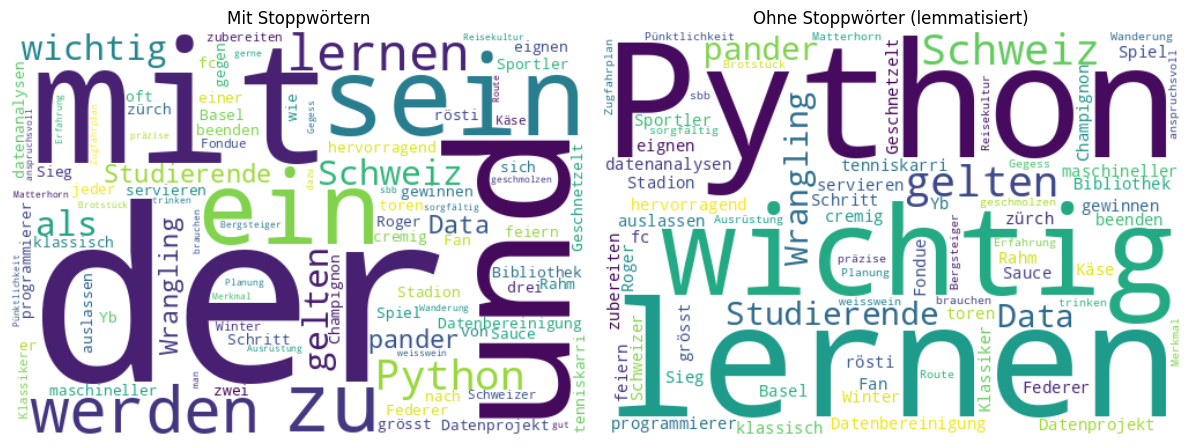

In [18]:
# Alle Tokens des Korpus, beide Varianten
tokens_mit_sw = []
tokens_ohne_sw = []
for text in korpus:
    tokens_mit_sw.extend(preprocess(text, entferne_stopw=False))
    tokens_ohne_sw.extend(preprocess(text, entferne_stopw=True))

text_mit = " ".join(tokens_mit_sw)
text_ohne = " ".join(tokens_ohne_sw)

wc_params = dict(width=500, height=350, background_color="white", random_state=42)
wc_mit = WordCloud(**wc_params).generate(text_mit)
wc_ohne = WordCloud(**wc_params).generate(text_ohne)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(wc_mit, interpolation="bilinear")
axes[0].set_title("Mit Stoppwörtern")
axes[0].axis("off")
axes[1].imshow(wc_ohne, interpolation="bilinear")
axes[1].set_title("Ohne Stoppwörter (lemmatisiert)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Typische Beobachtung:** In der linken Cloud dominieren Funktionswörter wie *der, die, und, mit*. Rechts treten Inhaltswörter wie *schweiz*, *daten*, *python*, *spiel* in den Vordergrund. Erst diese Cloud ist inhaltlich aussagekräftig.

## 6. Bag-of-Words

**Bag-of-Words (BoW)** repräsentiert jedes Dokument als Vektor von Wort-Häufigkeiten über ein festes Vokabular. Die Wortreihenfolge geht verloren — das Dokument ist ein «Sack voller Wörter».

`sklearn.feature_extraction.text.CountVectorizer` übernimmt Tokenisierung, Vokabular-Aufbau und Zählung in einem Schritt. Wir übergeben unsere `preprocess`-Funktion als Tokenizer, damit Lemmatisierung und Stoppwort-Filter konsistent angewendet werden.

In [19]:
count_vec = CountVectorizer(
    tokenizer=preprocess,
    token_pattern=None,   # da wir einen eigenen tokenizer liefern
    lowercase=False,      # unser preprocess macht schon .lower()
)

bow_matrix = count_vec.fit_transform(korpus)
vokabular = count_vec.get_feature_names_out()

print(f"Form der BoW-Matrix: {bow_matrix.shape}  (Dokumente × Vokabular)")
print(f"Vokabulargrösse:     {len(vokabular)}")

Form der BoW-Matrix: (8, 72)  (Dokumente × Vokabular)
Vokabulargrösse:     72


In [20]:
# Matrix als DataFrame anzeigen (nur für kleine Korpora sinnvoll!)
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vokabular,
    index=[f"doc_{i}" for i in range(len(korpus))]
)
bow_df

,Ausrüstung,Basel,Bergsteiger,Bibliothek,Brotstück,Champignon,Data,Datenbereinigung,Datenprojekt,Erfahrung,...,sbb,servieren,sorgfältig,tenniskarri,toren,trinken,weisswein,wichtig,zubereiten,zürch
doc_0,0,0,0,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,1,0,0
doc_1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
doc_2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
doc_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
doc_4,0,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
doc_5,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
doc_6,1,0,1,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
doc_7,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


### Übung 5 — Top-Begriffe pro Dokument aus BoW ★★☆

Ermittle für **jedes Dokument** die drei häufigsten Begriffe laut BoW-Matrix.

Die erwartete Ausgabe ist ein DataFrame mit den Spalten `doc_id`, `top1`, `top2`, `top3`.

_Tipp: `numpy.argsort` liefert Indizes von klein nach gross — verwende `[::-1]` zum Umkehren oder `argsort` auf `-row`._

In [21]:
# TODO: deine Lösung hier

#### Musterlösung 5

In [29]:
bow_array = bow_matrix.toarray()

top_rows = []
for i, row in enumerate(bow_array):
    top_idx = np.argsort(-row)[:3]
    top_woerter = [vokabular[j] for j in top_idx]
    top_rows.append([i] + top_woerter)

top_df = pd.DataFrame(top_rows, columns=["doc_id", "top1", "top2", "top3"])
top_df

,doc_id,top1,top2,top3
0,0,Data,Datenbereinigung,Datenprojekt
1,1,Bibliothek,lernen,programmierer
2,2,Basel,Fan,Sieg
3,3,Federer,Schweiz,Roger
4,4,Champignon,Geschnetzelt,Sauce
5,5,Brotstück,Fondue,Klassiker
6,6,Ausrüstung,Bergsteiger,Erfahrung
7,7,Schweiz,Reisekultur,Pünktlichkeit


**Beobachtung:** Die Top-Begriffe bleiben oft zu generisch. Wörter, die in fast jedem Dokument vorkommen (z.B. `schweiz`), erscheinen bei mehreren Dokumenten unter den Top-Wörtern — obwohl sie die Dokumente nicht voneinander unterscheiden. Genau hier setzt TF-IDF an.

## 7. TF-IDF

**TF-IDF** (Term Frequency – Inverse Document Frequency) gewichtet jedes Wort so, dass

- **häufige Wörter innerhalb eines Dokuments** ein hohes Gewicht bekommen (TF),
- **Wörter, die in vielen Dokumenten vorkommen**, abgewertet werden (IDF).

Formal:

$$\text{tf-idf}(t, d) = \text{tf}(t, d) \cdot \log \frac{N}{df(t)}$$

wobei $t$ = Term, $d$ = Dokument, $N$ = Anzahl Dokumente, $df(t)$ = Anzahl Dokumente, die $t$ enthalten.

Die Idee: Ein Wort ist *charakteristisch* für ein Dokument, wenn es **dort oft vorkommt, aber sonst nirgendwo**.

In [30]:
tfidf_vec = TfidfVectorizer(
    tokenizer=preprocess,
    token_pattern=None,
    lowercase=False,
)
tfidf_matrix = tfidf_vec.fit_transform(korpus)
tfidf_vokabular = tfidf_vec.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vokabular,
    index=[f"doc_{i}" for i in range(len(korpus))]
)
tfidf_df.round(2)

,Ausrüstung,Bergsteiger,Bibliothek,Brotstück,Champignon,Data,Datenbereinigung,Datenprojekt,Erfahrung,Fan,...,sorgfältig,tenniskarri,toren,trinken,weisswein,wichtig,x,y,zubereiten,zürch
doc_0,0.00,0.00,0.00,0.00,0.00,0.33,0.33,0.33,0.00,0.0,...,0.00,0.00,0.0,0.00,0.00,0.27,0.0,0.0,0.00,0.00
doc_1,0.00,0.00,0.36,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00
doc_2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.3,...,0.00,0.00,0.3,0.00,0.00,0.00,0.3,0.3,0.00,0.00
doc_3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.37,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00
doc_4,0.00,0.00,0.00,0.00,0.32,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.32,0.32
doc_5,0.00,0.00,0.00,0.32,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.0,0.32,0.32,0.00,0.0,0.0,0.00,0.00
doc_6,0.32,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.32,0.0,...,0.32,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.00,0.00
doc_7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.0,0.00,0.00,0.29,0.0,0.0,0.00,0.00


### Übung 6 — BoW vs. TF-IDF: Top-Begriffe vergleichen ★★☆

Ermittle für jedes Dokument die **drei höchstgewichteten Begriffe laut TF-IDF** und vergleiche sie mit den BoW-Top-Begriffen aus Übung 5.

**Leitfrage:** Welche Wörter «verschwinden» durch TF-IDF aus den Top-Listen? Welche rücken neu nach vorne — und warum sind diese inhaltlich oft aussagekräftiger?

In [24]:
# TODO: deine Lösung hier

#### Musterlösung 6

In [25]:
tfidf_array = tfidf_matrix.toarray()

tfidf_top_rows = []
for i, row in enumerate(tfidf_array):
    top_idx = np.argsort(-row)[:3]
    top_woerter = [tfidf_vokabular[j] for j in top_idx]
    tfidf_top_rows.append([i] + top_woerter)

tfidf_top_df = pd.DataFrame(tfidf_top_rows, columns=["doc_id", "top1_tfidf", "top2_tfidf", "top3_tfidf"])

# Gemeinsamer Vergleich:
vergleich_df = top_df.merge(tfidf_top_df, on="doc_id")
vergleich_df

,doc_id,top1,top2,top3,top1_tfidf,top2_tfidf,top3_tfidf
0,0,Data,Datenbereinigung,Datenprojekt,Data,Datenbereinigung,Datenprojekt
1,1,Bibliothek,lernen,programmierer,Bibliothek,python,programmierer
2,2,Basel,Fan,Sieg,Basel,Fan,Sieg
3,3,Federer,Schweiz,Roger,Federer,Roger,beenden
4,4,Champignon,Geschnetzelt,Sauce,Champignon,Geschnetzelt,Sauce
5,5,Brotstück,Fondue,Klassiker,Brotstück,Fondue,Klassiker
6,6,Ausrüstung,Bergsteiger,Erfahrung,Ausrüstung,Bergsteiger,Erfahrung
7,7,Schweiz,Reisekultur,Pünktlichkeit,Pünktlichkeit,Reisekultur,Merkmal


**Typische Erkenntnis:** Bei BoW tauchen generische Wörter in vielen Dokumenten auf. TF-IDF schiebt *charakteristische* Begriffe nach vorn — z.B. `matterhorn` für das Wander-Dokument, `federer` für das Tennis-Dokument, `python` für die Programmier-Dokumente. Genau solche Begriffe eignen sich später als Features für Klassifikation oder Clustering.

### Übung 7 — Eigene Preprocessing-Pipeline ★★★

Baue eine eigene Pipeline-Funktion `analyse(texte)`, die

1. einen neuen Text oder eine Liste von Texten entgegennimmt,
2. `preprocess` anwendet,
3. eine TF-IDF-Vektorisierung durchführt (wiederverwendet wird: **dasselbe** `tfidf_vec`, das oben auf dem Korpus trainiert wurde — also `transform`, nicht `fit_transform`),
4. pro neuem Text die **Top-3-Begriffe nach TF-IDF** zurückgibt.

**Teste deine Pipeline** mit diesen zwei neuen Texten:

```
"Im Winter fährt die SBB mit vollen Zügen ins Tessin, die Reise ist beliebt."
"Python-Skripte können Daten aus dem Internet laden und in ein Pandas DataFrame überführen."
```

**Zusatzfrage:** Warum ist es wichtig, für neue Texte `transform` (nicht `fit_transform`) zu verwenden?

In [26]:
# TODO: deine Lösung hier

#### Musterlösung 7

In [27]:
def analyse(texte):
    """Gibt für jeden Text die Top-3-Begriffe laut TF-IDF zurück."""
    if isinstance(texte, str):
        texte = [texte]
    matrix = tfidf_vec.transform(texte)   # transform, nicht fit_transform!
    vokab = tfidf_vec.get_feature_names_out()

    ergebnisse = []
    for i, row in enumerate(matrix.toarray()):
        top_idx = np.argsort(-row)[:3]
        top_woerter = [vokab[j] for j in top_idx if row[j] > 0]
        ergebnisse.append({"text": texte[i], "top_begriffe": top_woerter})
    return pd.DataFrame(ergebnisse)

neue_texte = [
    "Im Winter fährt die SBB mit vollen Zügen ins Tessin, die Reise ist beliebt.",
    "Python-Skripte können Daten aus dem Internet laden und in ein Pandas DataFrame überführen."
]

analyse(neue_texte)

,text,top_begriffe
0,"Im Winter fährt die SBB mit vollen Zügen ins Tessin, die Reise ist beliebt.","[sbb, Winter]"
1,Python-Skripte können Daten aus dem Internet laden und in ein Pandas DataFra...,[pander]


**Zur Zusatzfrage:** `fit_transform` würde auf den neuen Texten ein **neues Vokabular** und **neue IDF-Werte** berechnen. Damit wären die Vektoren der neuen Texte mit denen des Trainingskorpus nicht vergleichbar. `transform` verwendet das beim `fit` gelernte Vokabular und die gelernten IDF-Gewichte — genau das ist gewünscht, wenn man neue Texte in einen bestehenden Vektorraum einbetten will (z.B. für Klassifikation oder Ähnlichkeitssuche).

## 8. Wrap-up

Du hast in diesem Notebook die klassische Text-Pipeline durchlaufen:

| Schritt | Werkzeug | Was es liefert |
|---|---|---|
| Tokenisierung | `nltk.word_tokenize` | Liste von Wort-Tokens |
| Stemming | `SnowballStemmer("german")` | Abgeschnittene Wortstämme (schnell, grob) |
| Lemmatisierung | `spaCy de_core_news_sm` | Echte Grundformen (langsamer, semantisch sauber) |
| Stoppwort-Filter | NLTK + spaCy Listen | Inhaltsfokus statt Funktionswort-Rauschen |
| Bag-of-Words | `CountVectorizer` | Häufigkeits-Vektor pro Dokument |
| TF-IDF | `TfidfVectorizer` | Gewichteter Vektor, der Charakteristisches betont |

### Reflexionsfragen

1. In welchen Szenarien wäre **Stemming** gegenüber **Lemmatisierung** trotzdem die bessere Wahl?
2. Warum sind TF-IDF-Vektoren besser für Klassifikation oder Ähnlichkeitssuche geeignet als reine BoW-Vektoren?
3. Wann reichen die Stoppwort-Standardlisten von NLTK/spaCy **nicht** aus und man muss domänenspezifisch ergänzen?

### Ausblick

In den folgenden Sessions nutzen wir diese Vektoren als **Features** — etwa für Clustering, Klassifikation oder als Vorstufe für semantische Embeddings. Der Schritt von `TfidfVectorizer` zu modernen Sentence-Embeddings ist konzeptionell klein: statt Wort-Häufigkeiten stehen dann dichte, durch ein Modell gelernte Vektoren.